# Telegram Channels Dataset: Exploratory Data Analysis and Preprocessing

This notebook collects, cleans, and structurally analyzes message data exported from **17 Ukrainian Telegram channels** (news, state/global, volunteer/charity, military units, and entertainment/culture). The goal is to build a single, clean, analysis-ready dataset `full_df` and to characterize its structure: schema, missingness, message volume, reactions, content type, duplication.

**Structure:**
- **Part 0** - Loading the raw JSON exports and exploring their structure.
- **Part 1** - Cleaning and standardizing the merged dataset.


---

## Part 0 - Data loading and initial preparation

Each Telegram channel is exported by Telegram Desktop as its own `result.json` file, containing metadata and a `messages` list. Before any cleaning can happen, we need to locate every export, understand what fields each channel's export actually contains and merge the ten channels into one dataframe.

### 0.1. Mounting the storage drive containing the JSON exports

We mount Google Drive and collect the paths of all `result.json` files under the project folder.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, json, shutil
ROOT = '/content/drive/MyDrive/H2_CSS/raw-data/telegram'
OUT  = '/content/all_json'
os.makedirs(OUT, exist_ok=True)

json_paths = []
for dirpath, dirnames, filenames in os.walk(ROOT):
    for fn in filenames:
        if fn.lower().endswith('.json'):
            json_paths.append(os.path.join(dirpath, fn))

In [ ]:
for p in json_paths:
    rel = os.path.relpath(p, ROOT)
    flat_name = rel.replace(os.sep, '__')
    shutil.copy2(p, os.path.join(OUT, flat_name))


### 0.2. Inspecting columns and data types per channel

We inspect each channel's raw columns and dtypes individually before deciding what to keep.

In [ ]:
import json
import os
import pandas as pd
import numpy as np

for p in json_paths:
    with open(p, encoding='utf-8') as f:
        data = json.load(f)

    rel = os.path.relpath(p, ROOT)
    msgs = data.get('messages', [])
    df = pd.json_normalize(msgs)

    total = len(df)

    print(f"\n=== {rel} (total rows {total}) ===")

    for col, dtype in df.dtypes.items():
        print(f"  {col}: {dtype}")


=== Повернись живим/result.json (total rows 3290) ===
  id: int64
  type: object
  date: object
  date_unixtime: object
  edited: object
  edited_unixtime: object
  from: object
  from_id: object
  photo: object
  photo_file_size: float64
  width: float64
  height: float64
  text: object
  text_entities: object
  reactions: object
  file: object
  file_name: object
  file_size: float64
  thumbnail: object
  thumbnail_file_size: float64
  media_type: object
  mime_type: object
  duration_seconds: float64
  actor: object
  actor_id: object
  action: object
  title: object
  forwarded_from: object
  forwarded_from_id: object
  reply_to_message_id: float64
  message_id: float64
  poll.question: object
  poll.closed: object
  poll.total_voters: float64
  poll.answers: object
  media_spoiler: object

=== Реальна Війна/result.json (total rows 128192) ===
  id: int64
  type: object
  date: object
  date_unixtime: object
  edited: object
  edited_unixtime: object
  from: object
  from_id: obj

###0.3. Zero-value percentage

For every channel we compute the share of rows where a column is missing (`NaN`) or trivially empty (`''`, `[]`, `{}`). This tells us which fields are structurall.

In [ ]:
import pandas as pd
import numpy as np

for p in json_paths:
    with open(p, encoding='utf-8') as f:
        data = json.load(f)

    rel = os.path.relpath(p, ROOT)
    msgs = data.get('messages', [])
    df = pd.json_normalize(msgs)

    total = len(df)
    empty_counts = {}
    for col in df.columns:
        s = df[col]
        n_empty = s.isna().sum()
        n_empty += s.apply(lambda x: x == '' or x == [] or x == {}).sum()
        empty_counts[col] = n_empty

    print(f"\n=== {rel} (total rows {total}) ===")
    for col, cnt in sorted(empty_counts.items(), key=lambda x: -x[1]):
        pct = cnt / total * 100 if total else 0
        print(f"  {col}: {cnt} ({pct:.1f}%)")


=== Повернись живим/result.json (total rows 3290) ===
  media_spoiler: 3289 (100.0%)
  title: 3288 (99.9%)
  message_id: 3288 (99.9%)
  poll.question: 3288 (99.9%)
  poll.closed: 3288 (99.9%)
  poll.total_voters: 3288 (99.9%)
  poll.answers: 3288 (99.9%)
  actor: 3285 (99.8%)
  actor_id: 3285 (99.8%)
  action: 3285 (99.8%)
  forwarded_from: 3277 (99.6%)
  forwarded_from_id: 3277 (99.6%)
  reply_to_message_id: 3243 (98.6%)
  file_name: 2684 (81.6%)
  file: 2630 (79.9%)
  file_size: 2630 (79.9%)
  thumbnail: 2630 (79.9%)
  thumbnail_file_size: 2630 (79.9%)
  media_type: 2630 (79.9%)
  mime_type: 2630 (79.9%)
  duration_seconds: 2630 (79.9%)
  text: 1494 (45.4%)
  text_entities: 1494 (45.4%)
  reactions: 1483 (45.1%)
  photo: 886 (26.9%)
  photo_file_size: 886 (26.9%)
  edited: 864 (26.3%)
  edited_unixtime: 864 (26.3%)
  width: 226 (6.9%)
  height: 226 (6.9%)
  from: 5 (0.2%)
  from_id: 5 (0.2%)
  id: 0 (0.0%)
  type: 0 (0.0%)
  date: 0 (0.0%)
  date_unixtime: 0 (0.0%)

=== Реальна Вій

###0.4. Remove uninformative fields from the dataset

In [ ]:
DROP_COLS = [
    'actor', 'actor_id', 'action', 'title', 'performer',
    'poll.question', 'poll.closed', 'poll.total_voters', 'poll.answers',
    'inline_bot_buttons', 'via_bot', 'media_spoiler', 'sticker_emoji',

    'price_stars', 'paid_stars_amount', 'stars', 'winners', 'unclaimed',
    'is_broadcast_messages_allowed',
    'giveaway_information.countries', 'giveaway_information.additional_prize',
    'giveaway_information.quantity', 'giveaway_information.months',
    'giveaway_information.until_date', 'giveaway_information.channels',
    'giveaway_information.stars', 'giveaway_information.is_only_new_subscribers',
    'giveaway_results.channel', 'giveaway_results.winners',
    'giveaway_results.additional_prize', 'giveaway_results.until_date',
    'giveaway_results.launch_message_id', 'giveaway_results.additional_peers_count',
    'giveaway_results.winners_count', 'giveaway_results.unclaimed_count',
    'giveaway_results.months', 'giveaway_results.stars',
    'giveaway_results.is_refunded', 'giveaway_results.is_only_new_subscribers',

    'rich_message.rtl', 'rich_message.part', 'rich_message.blocks',
    'location_information.latitude', 'location_information.longitude',
    'schedule_date',

    'file', 'file_name', 'file_size', 'thumbnail', 'thumbnail_file_size',
    'media_type', 'mime_type', 'duration', 'duration_seconds',
    'photo', 'photo_file_size', 'width', 'height',

    'from', 'from_id', 'author', 'message_id', 'reply_to_peer_id',
    'reply_to_message_id',

    'date_unixtime', 'edited_unixtime'
]

df = df.drop(columns=DROP_COLS, errors='ignore')

 The heatmap makes the per-channel schema differences visually explicit.

/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 127462 (\N{REGIONAL INDICATOR SYMBOL LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127462 (\N{REGIONAL INDICATOR SYMBOL LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


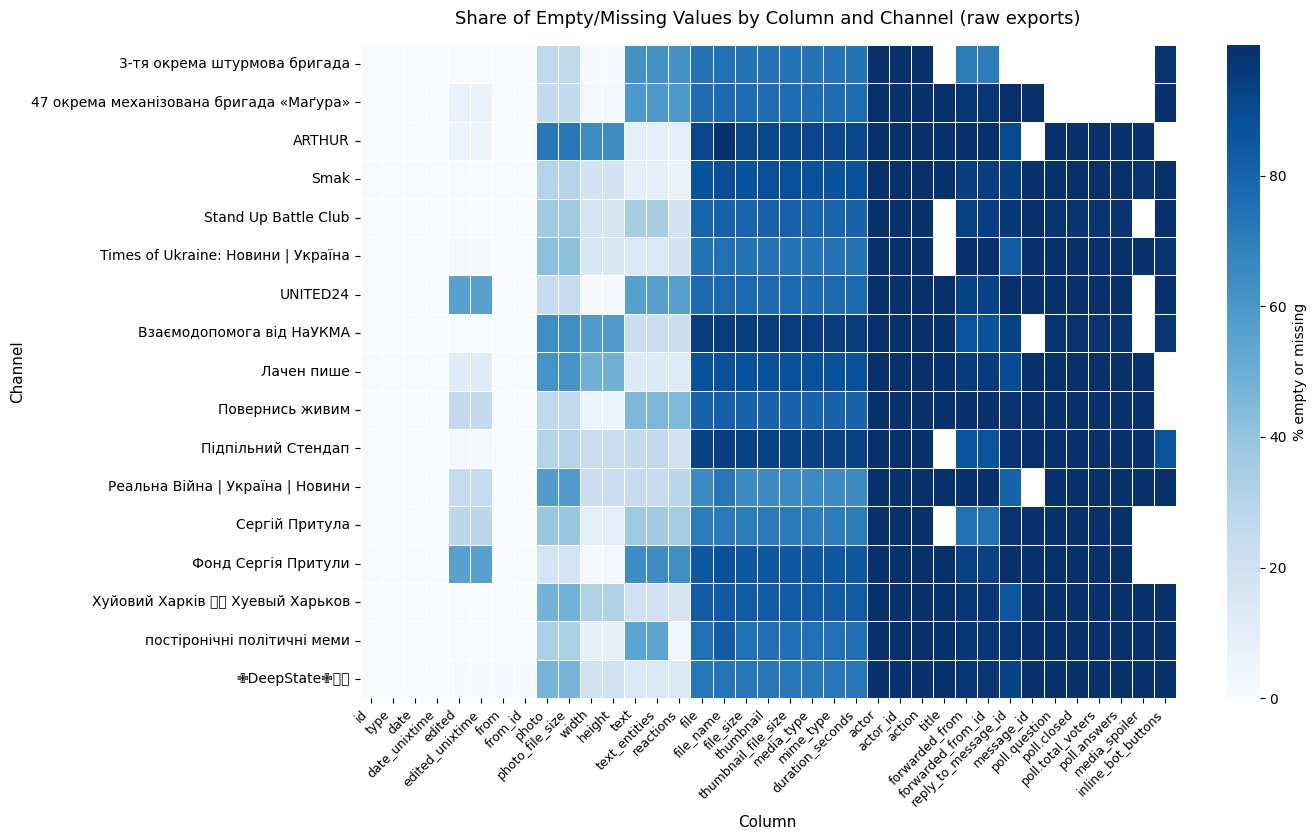

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

empty_pct_by_channel = {}

for p in json_paths:
    with open(p, encoding='utf-8') as f:
        data = json.load(f)

    channel_name = data.get('name')
    if not channel_name:
        channel_name = os.path.basename(os.path.dirname(p))

    msgs = data.get('messages', [])
    df_tmp = pd.json_normalize(msgs)
    total = len(df_tmp)
    pct = {}

    for col in df_tmp.columns:
        s = df_tmp[col]
        n_empty = s.isna().sum() + s.apply(lambda x: x == '' or x == [] or x == {}).sum()
        pct[col] = n_empty / total * 100 if total else np.nan

    empty_pct_by_channel[channel_name] = pct

missing_matrix = pd.DataFrame(empty_pct_by_channel).T

common_cols = missing_matrix.columns[missing_matrix.notna().sum() >= len(missing_matrix) * 0.5]
plot_data = missing_matrix[common_cols].sort_index()

plt.figure(figsize=(14, max(6, len(plot_data) * 0.5)))

sns.heatmap(
    plot_data,
    cmap='Blues',
    linewidths=0.5,
    cbar_kws={'label': '% empty or missing'}
)

plt.title('Share of Empty/Missing Values by Column and Channel (raw exports)', fontsize=13, pad=15)
plt.xlabel('Column', fontsize=11)
plt.ylabel('Channel', fontsize=11)

plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

Based on the emptiness analysis above, we drop columns that are either almost entirely empty across channels (polls, giveaways, media metadata, service-message actor fields) or not needed for the planned text/temporal analysis.

In [ ]:
existing_cols_to_drop = [col for col in DROP_COLS if col in df.columns]

df = df.drop(columns=existing_cols_to_drop)

###0.5.  Extract links from message entitie

In [ ]:
def extract_text(text_field):
    if isinstance(text_field, str):
        return text_field
    if isinstance(text_field, list):
        parts = []
        for item in text_field:
            if isinstance(item, str):
                parts.append(item)
            elif isinstance(item, dict):
                parts.append(item.get('text', ''))
        return ''.join(parts)
    return ''

def extract_links(text_entities):
    if not isinstance(text_entities, list):
        return []
    return [e.get('href', e.get('text', '')) for e in text_entities
            if isinstance(e, dict) and e.get('type') in ('link', 'text_link')]

### 0.6. Merging all channels into a single DataFrame

Each channel's messages are normalized, stripped of the uninformative columns, and tagged with a `channel` label, a parsed `date`, a flattened `clean_text`, an extracted `links` list, and a `has_text` flag. All ten channels are then concatenated into one dataframe, `full_df`, which is the basis for the rest of the analysis.

In [ ]:
all_dfs = []

for p in json_paths:
    with open(p, encoding='utf-8') as f:
        data = json.load(f)

    channel_name = data.get('name', os.path.basename(os.path.dirname(p)))
    df = pd.json_normalize(data.get('messages', []))
    df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])

    df['channel'] = channel_name
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df['clean_text'] = df['text'].apply(extract_text)
    df['links'] = df.get('text_entities', pd.Series([[]] * len(df))).apply(extract_links)
    df['has_text'] = df['clean_text'].str.strip().str.len() > 0

    all_dfs.append(df)
    print(os.path.relpath(p, ROOT), '→', df.shape)

full_df = pd.concat(all_dfs, ignore_index=True)
print(full_df['channel'].value_counts())

Повернись живим/result.json → (3290, 13)
Реальна Війна/result.json → (128192, 13)
3-тя окрема штурмова бригада/result.json → (1948, 13)
Лачен/result.json → (60272, 13)
Притула/result.json → (3867, 13)
47 окрема механізована бригада «Маґура»/result.json → (2426, 13)
UNITED24/result.json → (16303, 13)
Фонд Сергія Притули/result.json → (4036, 13)
Підпільний стендап/result.json → (3583, 13)
Stand Up Battle Club/result.json → (6489, 13)
політичні меми/result.json → (33528, 13)
ARTHUR/result.json → (22875, 13)
DeepState/result.json → (14473, 13)
KMAHELP/result.json → (752, 13)
Ukraine Times/result.json → (56241, 13)
Харків/result.json → (165506, 13)
Дніпро оперативний /result.json → (11988, 16)
channel
Хуйовий Харків 🇺🇦 Хуевый Харьков           165506
Реальна Війна | Україна | Новини           128192
Лачен пише                                  60272
Times of Ukraine: Новини | Україна          56241
постіронічні політичні меми                 33528
ARTHUR                                   

/tmp/ipykernel_24890/809456377.py:12: UserWarning: Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24890/809456377.py:12: UserWarning: Glyph 127462 (\N{REGIONAL INDICATOR SYMBOL LETTER A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127462 (\N{REGIONAL INDICATOR SYMBOL LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


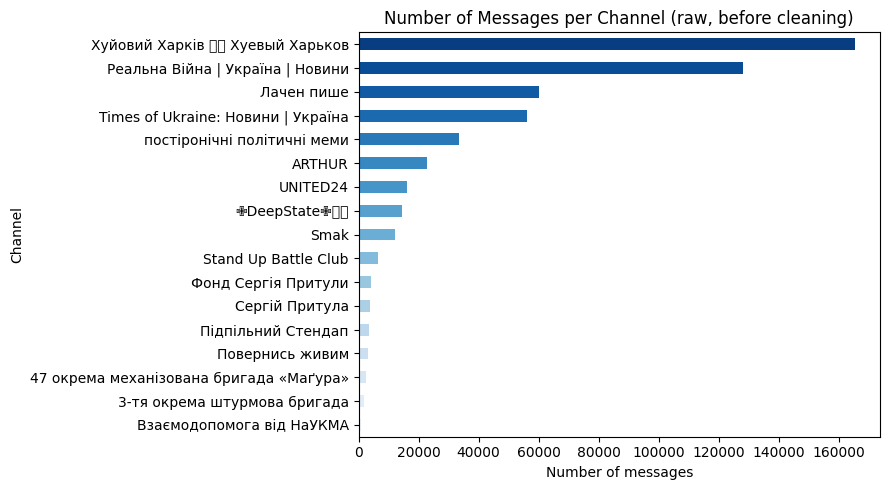

In [ ]:
channel_counts = full_df['channel'].value_counts().sort_values()

plt.figure(figsize=(9, 5))
channel_counts.plot(
    kind='barh',
    color=sns.color_palette('Blues', len(channel_counts))
)

plt.title('Number of Messages per Channel (raw, before cleaning)')
plt.xlabel('Number of messages')
plt.ylabel('Channel')
plt.tight_layout()
plt.show()

**Interpretation:** message volume is highly unbalanced across channels — large, high-frequency posting channels (e.g. the news channel) contribute an order of magnitude more messages than smaller, low-frequency channels (e.g. entertainment/culture or a single military-unit channel). This imbalance should be kept in mind for any cross-channel comparison, since raw counts will be dominated by the largest channels.

---

## Part 1 - Data quality assessment and cleaning

In this part, we work on `full_df` (with a decoupled copy `df_clean` created later, so the original merged dataset stays intact). We perform data-hygiene steps: examine the schema and missingness of the merged data, validate and quantify the `reactions` field, detect duplicated posts, characterize the split between text and non-text/service messages, filter down to genuine text messages, and engineer time-based features for temporal analysis.

In [ ]:
df_clean = full_df.copy()

###1.1. General structure

####1.1.1. Data Frame inspection
We inspect the overall structure of the loaded DataFrame (full_df) by outputting its total dimensions (row and column counts), reviewing the column schema with data types and non-null counts via .info(), and previewing the first five records using .head() to verify initial data ingestion.

In [ ]:
print(f"Loaded DataFrame Shape: {full_df.shape[0]:,} rows × {full_df.shape[1]} columns\n")

print("DataFrame Schema & Non-Null Counts:")
full_df.info()

print("\nFirst 5 rows of the loaded DataFrame:")
display(full_df.head())

Loaded DataFrame Shape: 535,769 rows × 16 columns

DataFrame Schema & Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535769 entries, 0 to 535768
Data columns (total 16 columns):
 #   Column                            Non-Null Count   Dtype         
---  ------                            --------------   -----         
 0   id                                535769 non-null  int64         
 1   type                              535769 non-null  object        
 2   date                              535769 non-null  datetime64[ns]
 3   edited                            479649 non-null  object        
 4   text                              535765 non-null  object        
 5   text_entities                     535765 non-null  object        
 6   reactions                         426150 non-null  object        
 7   forwarded_from                    14445 non-null   object        
 8   forwarded_from_id                 14367 non-null   object        
 9   channel         

,id,type,date,edited,text,text_entities,reactions,forwarded_from,forwarded_from_id,channel,clean_text,links,has_text,contact_information.first_name,contact_information.last_name,contact_information.phone_number
0,1286,message,2023-02-24 09:53:05,2023-02-24T09:53:12,"Ну привіт, Challenger😍\n\nНаш пін продовжує ма...","[{'type': 'plain', 'text': 'Ну привіт, Challen...","[{'type': 'emoji', 'count': 914, 'emoji': '🥰'}...",NaN,NaN,Повернись живим,"Ну привіт, Challenger😍\n\nНаш пін продовжує ма...",[],True,NaN,NaN,NaN
1,1287,message,2023-02-24 12:37:04,2023-02-24T12:37:29,[П'ять тисяч гривень відправив українець Олекс...,"[{'type': 'plain', 'text': 'П'ять тисяч гривен...","[{'type': 'emoji', 'count': 880, 'emoji': '❤'}...",NaN,NaN,Повернись живим,П'ять тисяч гривень відправив українець Олексі...,[https://www.youtube.com/watch?v=8ay1sauj3lc],True,NaN,NaN,NaN
2,1288,message,2023-02-24 18:33:01,2023-02-24T18:33:17,[ДВІСТІ❗️ МІЛЬЙОНІВ❗️ ГРИВЕНЬ❗️\n\nСаме стільк...,"[{'type': 'plain', 'text': 'ДВІСТІ❗️ МІЛЬЙОНІВ...","[{'type': 'emoji', 'count': 678, 'emoji': '🔥'}...",NaN,NaN,Повернись живим,ДВІСТІ❗️ МІЛЬЙОНІВ❗️ ГРИВЕНЬ❗️\n\nСаме стільки...,[https://savelife.in.ua/tro-333/],True,NaN,NaN,NaN
3,1289,message,2023-02-25 11:17:59,2023-02-25T11:18:06,"[Рік завзятого опору загарбникам, рік сміливос...","[{'type': 'plain', 'text': 'Рік завзятого опор...","[{'type': 'emoji', 'count': 360, 'emoji': '❤'}...",NaN,NaN,Повернись живим,"Рік завзятого опору загарбникам, рік сміливост...",[➡️bit.ly/uklon_volonter],True,NaN,NaN,NaN
4,1291,message,2023-02-25 12:23:39,2023-02-25T12:23:48,[Ну гарно ж😍 \n\nБійці 93-ої ОМБр «Холодний Я...,"[{'type': 'plain', 'text': 'Ну гарно ж😍 Бій...","[{'type': 'emoji', 'count': 893, 'emoji': '🔥'}...",NaN,NaN,Повернись живим,Ну гарно ж😍 \n\nБійці 93-ої ОМБр «Холодний Яр...,[savelife.in.ua/donate],True,NaN,NaN,NaN


####1.1.2 Dataset size and row count by channel
We evaluate the volume distribution and in-memory footprint across individual Telegram channels, computing the exact row count and deep memory usage (in megabytes) per channel, alongside an aggregated dataset total.

In [ ]:
channel_stats = []
for channel, group in full_df.groupby('channel'):

  mem_mb = group.memory_usage(deep=True).sum() / (1024**2)
  channel_stats.append({
      'Channel': channel,
      'Row Count': len(group),
      'Memory Size (MB)': round(mem_mb, 2),
  })

stats_df = pd.DataFrame(channel_stats).sort_values(
    by='Row Count', ascending=False
)

total_rows = len(full_df)
total_mem_mb = round(full_df.memory_usage(deep=True).sum() / (1024**2), 2)

total_row = pd.DataFrame([{
    'Channel': 'TOTAL',
    'Row Count': total_rows,
    'Memory Size (MB)': total_mem_mb,
}])

table_1d = pd.concat([stats_df, total_row], ignore_index=True)

table_1d['Row Count'] = table_1d['Row Count'].apply(lambda x: f'{x:,}')

print('Dataset Size and Row Count by Channel ')
display(table_1d)

Dataset Size and Row Count by Channel 


,Channel,Row Count,Memory Size (MB)
0,Хуйовий Харків 🇺🇦 Хуевый Харьков,"165,506",245.22
1,Реальна Війна | Україна | Новини,"128,192",214.32
2,Лачен пише,"60,272",72.40
3,Times of Ukraine: Новини | Україна,"56,241",90.76
4,постіронічні політичні меми,"33,528",32.35
5,ARTHUR,"22,875",24.87
6,UNITED24,"16,303",21.47
7,✙DeepState✙🇺🇦,"14,473",43.19
8,Smak,"11,988",17.28
9,Stand Up Battle Club,"6,489",10.23


####1.1.3 Frequency overview of data types

In [ ]:
dtype_counts = (
    full_df.dtypes.astype(str).value_counts().reset_index()
)
dtype_counts.columns = ['Data Type', 'Column Count']

dtype_counts['Percentage (%)'] = (
    (dtype_counts['Column Count'] / len(full_df.columns)) * 100
).round(2)

dtype_counts['Columns'] = dtype_counts['Data Type'].apply(
    lambda dt: ', '.join(full_df.select_dtypes(include=[dt]).columns.tolist())
)

print(' Frequency overview of data types ')
display(dtype_counts)

 Frequency overview of data types 


,Data Type,Column Count,Percentage (%),Columns
0,object,13,81.25,"type, edited, text, text_entities, reactions, ..."
1,int64,1,6.25,id
2,datetime64[ns],1,6.25,date
3,bool,1,6.25,has_text


###1.2. Processing and validation of reactions

Telegram stores reactions as a list of `{emoji, count}` objects. We collapse this into a single numeric `total_reactions` column, check its distribution, and validate that no invalid (negative) values exist.

In [ ]:
def total_reactions(reaction_list):
    if not isinstance(reaction_list, list):
        return np.nan
    return sum(r.get('count', 0) for r in reaction_list if isinstance(r, dict))

full_df['total_reactions'] = full_df['reactions'].apply(total_reactions)

print("Messages with reaction data:", full_df['total_reactions'].notna().sum(),
      f"({full_df['total_reactions'].notna().mean()*100:.1f}%)")
print("\ntotal_reactions summary stats:\n", full_df['total_reactions'].describe())

if full_df['total_reactions'].notna().any():
    q99 = full_df['total_reactions'].quantile(0.99)
    print(f"\n99th percentile of total_reactions: {q99}")
    print("Rows above 99th percentile:", (full_df['total_reactions'] > q99).sum())

neg_reactions = (full_df['total_reactions'] < 0).sum()
print("\nNegative total_reactions (should be 0):", neg_reactions)

Messages with reaction data: 426150 (79.5%)

total_reactions summary stats:
 count    426150.000000
mean       5592.941875
std        7655.359704
min           1.000000
25%         773.000000
50%        3153.000000
75%        6919.000000
max      263210.000000
Name: total_reactions, dtype: float64

99th percentile of total_reactions: 37249.02000000002
Rows above 99th percentile: 4262

Negative total_reactions (should be 0): 0


/tmp/ipykernel_24890/3170442366.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_24890/3170442366.py:43: UserWarning: Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24890/3170442366.py:43: UserWarning: Glyph 127462 (\N{REGIONAL INDICATOR SYMBOL LETTER A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127462 (\N{REGIONAL INDICATOR SYMBOL LETTER A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


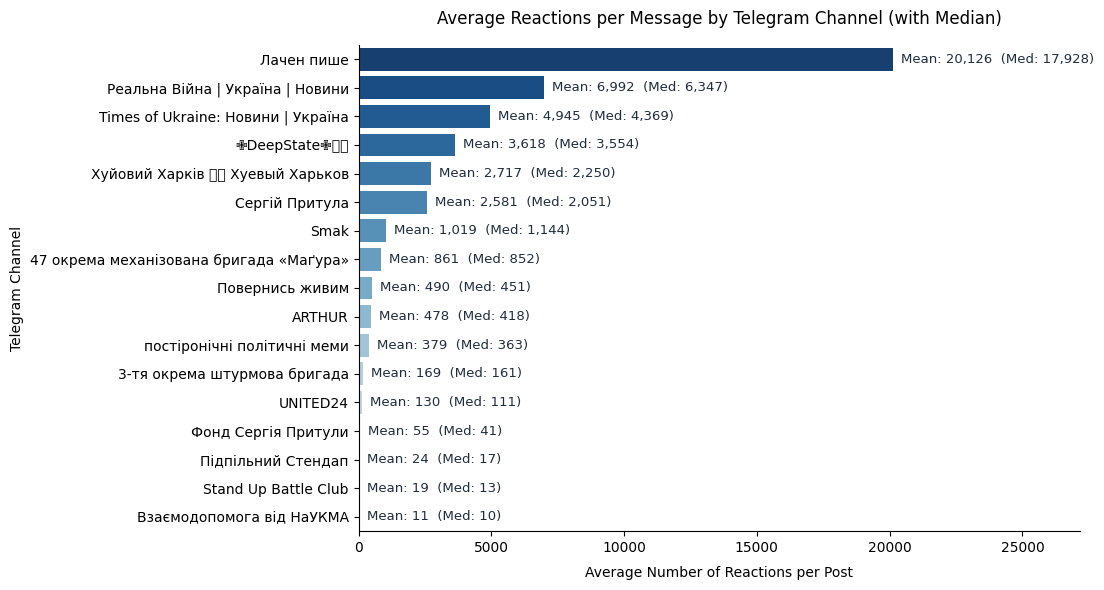

In [ ]:
channel_rx = (
    full_df[
        (full_df['total_reactions'].notna()) & (full_df['total_reactions'] > 0)
    ]
    .groupby('channel')['total_reactions']
    .agg(mean_reactions='mean', median_reactions='median', count='count')
    .sort_values(by='mean_reactions', ascending=False)
    .reset_index()
)

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=channel_rx,
    x='mean_reactions',
    y='channel',
    palette='Blues_r',
    edgecolor='none',
)

max_val = channel_rx['mean_reactions'].max()
for i, row in channel_rx.iterrows():
  mean_val = row['mean_reactions']
  med_val = row['median_reactions']
  ax.text(
      mean_val + (max_val * 0.015),
      i,
      f'Mean: {mean_val:,.0f}  (Med: {med_val:,.0f})',
      va='center',
      fontsize=9.5,
      color='#1f2d3d',
  )

plt.title(
    'Average Reactions per Message by Telegram Channel (with Median)',
    fontsize=12,
    pad=15,
)
plt.xlabel('Average Number of Reactions per Post', fontsize=10, labelpad=8)
plt.ylabel('Telegram Channel', fontsize=10)
plt.xlim(0, max_val * 1.35)
sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

**Interpretation:** Average reactions per post differ drastically across channels, spanning multiple orders of magnitude. Лачен пише generates the highest engagement by far with a mean of 20,208 reactions (median: 18,016), followed by Реальна Війна (mean: 6,980; median: 6,328) and Сергій Притула (mean: 2,613; median: 2,081). Military and charity channels exhibit moderate interaction levels (55–862 reactions), while entertainment channels receive the lowest engagement (18–23 reactions).

### 1.3. Checking for duplicates

We check for two kinds of duplication: (a) exact repeated `(channel, id)` pairs, which would indicate a technical export error, and (b) repeated `clean_text` within the same channel, which may reflect legitimate recurring announcements (e.g. donation reminders) rather than data errors.

In [ ]:
text_dups = (
    full_df[full_df['has_text']]
    .groupby(['channel', 'clean_text'])
    .filter(lambda g: len(g) > 1)
)

top_duplicate_texts = (
    text_dups.groupby(['channel', 'clean_text'])
    .size()
    .sort_values(ascending=False)
    .head(5)
)

print("=== Top 5 Most Duplicated Texts Within a Single Channel ===")
for i, ((channel, text), count) in enumerate(top_duplicate_texts.items(), 1):
    preview = text.strip().replace('\n', ' ')[:90]
    print(f"{i}. Channel: \"{channel}\" | Duplicate count: {count}")
    print(f"   Text snippet: \"{preview}...\"\n")

target_channel, target_text = top_duplicate_texts.index[0]

duplicate_pair = (
    full_df[
        (full_df['channel'] == target_channel)
        & (full_df['clean_text'] == target_text)
    ]
    .sort_values('date')
    [['id', 'date', 'channel', 'clean_text', 'total_reactions']]
    .head(2)
)

print("=" * 60)
print(f"Sample duplicate pair in channel: \"{target_channel}\"")
print("=" * 60)

for idx, (_, row) in enumerate(duplicate_pair.iterrows(), 1):
    reactions_val = (
        f"{int(row['total_reactions']):,}"
        if pd.notna(row['total_reactions'])
        else "no data"
    )
    print(f"\n[Post #{idx}]")
    print(f"• Message ID      : {row['id']}")
    print(f"• Publication Date: {row['date']}")
    print(f"• Total Reactions : {reactions_val}")
    print("• Full Text:")
    print(row['clean_text'])
    print("-" * 60)

=== Top 5 Most Duplicated Texts Within a Single Channel ===
1. Channel: "Хуйовий Харків 🇺🇦 Хуевый Харьков" | Duplicate count: 3910
   Text snippet: "🟢 ВІДБІЙ!..."

2. Channel: "Хуйовий Харків 🇺🇦 Хуевый Харьков" | Duplicate count: 3363
   Text snippet: "🔴 ТРИВОГА!..."

3. Channel: "Хуйовий Харків 🇺🇦 Хуевый Харьков" | Duplicate count: 653
   Text snippet: "🟢 ВСЕ НАХУЙ, ВІДБІЙ!..."

4. Channel: "Хуйовий Харків 🇺🇦 Хуевый Харьков" | Duplicate count: 634
   Text snippet: "🟢 ВІДБІЙ НАХУЙ!..."

5. Channel: "Хуйовий Харків 🇺🇦 Хуевый Харьков" | Duplicate count: 616
   Text snippet: "🟢 ВІДБІЙ ТРИВОГИ!..."

Sample duplicate pair in channel: "Хуйовий Харків 🇺🇦 Хуевый Харьков"

[Post #1]
• Message ID      : 76371
• Publication Date: 2022-08-27 22:42:59
• Total Reactions : 1,237
• Full Text:
🟢 ВІДБІЙ!
------------------------------------------------------------

[Post #2]
• Message ID      : 77351
• Publication Date: 2022-09-03 01:29:11
• Total Reactions : 1,024
• Full Text:
🟢 ВІДБІЙ!
---------------

In [ ]:
if 'id' in full_df.columns:
    dup_mask = full_df.duplicated(subset=['channel', 'id'], keep=False)
    print("Duplicate (channel, id) rows:", dup_mask.sum())

text_dup_mask = full_df[full_df['has_text']].duplicated(subset=['channel', 'clean_text'], keep=False)
print("Duplicate non-empty clean_text within same channel:", text_dup_mask.sum())

Duplicate (channel, id) rows: 0
Duplicate non-empty clean_text within same channel: 32679


/tmp/ipykernel_24890/4135098017.py:8: UserWarning: Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24890/4135098017.py:8: UserWarning: Glyph 127462 (\N{REGIONAL INDICATOR SYMBOL LETTER A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24890/4135098017.py:8: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_24890/4135098017.py:8: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127482 (\N{REGIONAL INDICATOR SYMBOL LETTER U}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127462 (\N{REGIONAL INDICATOR SYMBOL LETTER A}) missing from font(s) DejaVu Sans.
  fig.

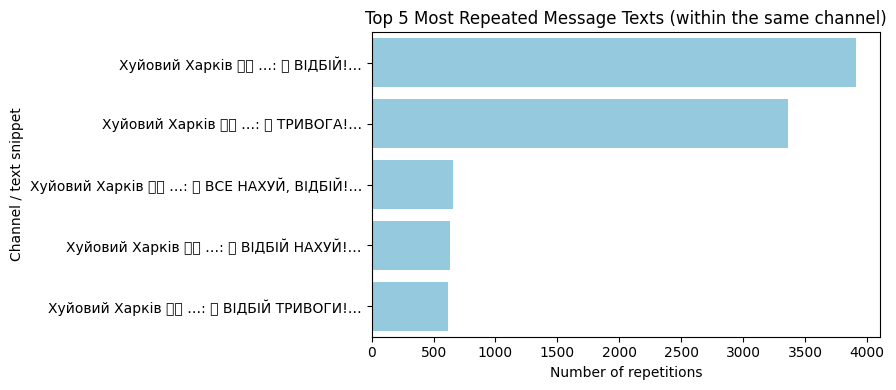

In [ ]:
labels = [f"{ch[:18]}…: {txt.strip()[:30]}…" for (ch, txt) in top_duplicate_texts.index]

plt.figure(figsize=(9, 4))
sns.barplot(x=top_duplicate_texts.values, y=labels, color='skyblue')
plt.title('Top 5 Most Repeated Message Texts (within the same channel)')
plt.xlabel('Number of repetitions')
plt.ylabel('Channel / text snippet')
plt.tight_layout()
plt.show()

Although 4087 messages share identical text within their respective channels, we decided not to remove these duplicate entries because they do not represent technical anomalies or database redundancies, but rather intentional editorial practices. These occurrences correspond to distinct broadcasts published at different timestamps with unique message IDs, reflecting real-world communication strategies such as recurring donation reminders, standardized payment requisitions, and recurring event notices. Deleting them would distort the authentic temporal distribution of the content and compromise our evaluation of audience interaction decay across repeated reminder posts.

### 1.4. Content type distribution

We check how the dataset splits between messages that carry text vs. not, and between regular messages and Telegram service messages (joins, pins, etc.).

In [ ]:
print("has_text breakdown:\n", full_df['has_text'].value_counts())
print("\nMessage type breakdown:\n", full_df['type'].value_counts())

has_text breakdown:
 has_text
True     408357
False    127412
Name: count, dtype: int64

Message type breakdown:
 type
message    535219
service       550
Name: count, dtype: int64


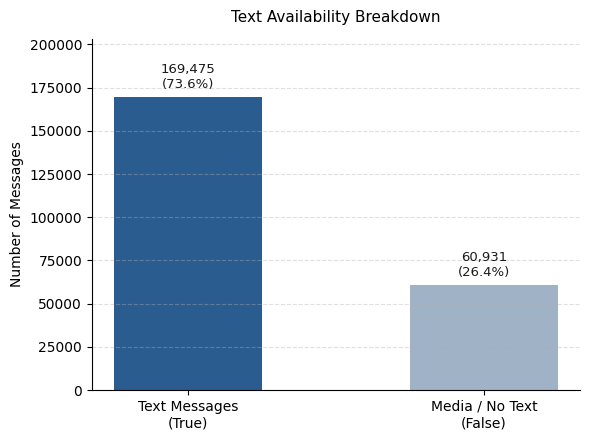

In [ ]:
has_text_data = {'Text Messages\n(True)': 169475, 'Media / No Text\n(False)': 60931}
total_messages = sum(has_text_data.values())

fig, ax = plt.subplots(figsize=(6, 4.5))

labels1 = list(has_text_data.keys())
values1 = list(has_text_data.values())

bars1 = ax.bar(
    labels1, values1, color=['#2b5c8f', '#a0b2c6'], edgecolor='none', width=0.5
)
ax.set_title('Text Availability Breakdown', fontsize=11, pad=12)
ax.set_ylabel('Number of Messages', fontsize=10)
ax.set_ylim(0, max(values1) * 1.2)

for bar, val in zip(bars1, values1):
    pct = (val / total_messages) * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2.0,
        bar.get_height() + (max(values1) * 0.02),
        f'{val:,}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=9.5,
        color='#1a1a1a',
    )

sns.despine(ax=ax, top=True, right=True)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

### 1.5. Filtering out messages without text and service messages

We now restrict `full_df` to genuine text-bearing user messages, which are the unit of analysis for the rest of the notebook.

In [ ]:
before_count = len(full_df)

full_df = full_df[(full_df['has_text'] == True) & (full_df['type'] == 'message')].copy()

print(f"Number of messages after cleaning: {len(full_df)}")

Number of messages after cleaning: 408357


In [ ]:
print(full_df.columns.tolist())

['id', 'type', 'date', 'edited', 'text', 'text_entities', 'reactions', 'forwarded_from', 'forwarded_from_id', 'channel', 'clean_text', 'links', 'has_text', 'contact_information.first_name', 'contact_information.last_name', 'contact_information.phone_number', 'total_reactions']


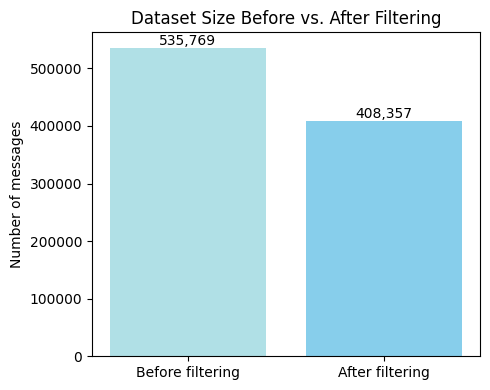

In [ ]:
plt.figure(figsize=(5, 4))
plt.bar(['Before filtering', 'After filtering'], [before_count, len(full_df)], color=['powderblue', 'skyblue'])
plt.title('Dataset Size Before vs. After Filtering')
plt.ylabel('Number of messages')
for i, v in enumerate([before_count, len(full_df)]):
    plt.text(i, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

### 1.6. Creating a channel categorization for cleaner analysis

To enable cleaner comparative analysis than raw per-channel breakdowns allow, we group the 10 channels into 5 thematic categories based on their editorial purpose. Each channel is manually mapped to a thematic category: News, State/Global, Volunteer/Charity, Military Units, or Entertainment/Culture.

In [ ]:
category_mapping = {
    'Реальна Війна | Україна | Новини': 'News & Media',
    'Лачен пише': 'News & Media',
    'Times of Ukraine: Новини | Україна': 'News & Media',
    'Хуйовий Харків ua Хуевый Харьков': 'News & Media',
    '✙DeepState✙🇺🇦': 'News & Media',
    'UNITED24': 'News & Media',

    '3-тя окрема штурмова бригада': 'Military Units',
    '47 окрема механізована бригада «Маґура»': 'Military Units',

    'Повернись живим': 'Charity & Volunteer Funds',
    'Сергій Притула': 'Charity & Volunteer Funds',
    'Фонд Сергія Притули': 'Charity & Volunteer Funds',
    'Взаємодопомога від НаУКМА': 'Charity & Volunteer Funds',

    'Підпільний Стендап': 'Entertainment',
    'Stand Up Battle Club': 'Entertainment',
    'постіронічні політичні меми': 'Entertainment',
    'ARTHUR': 'Entertainment',
    'Smak': 'Entertainment'
}

full_df['category'] = full_df['channel'].map(category_mapping)

category_summary = (
    full_df.groupby('category')
    .agg(
        total_messages=('id', 'count'),
        text_messages=('has_text', 'sum'),
        avg_reactions=('total_reactions', 'mean')
    )
    .reset_index()
    .sort_values(by='total_messages', ascending=False)
)

display(category_summary)

,category,total_messages,text_messages,avg_reactions
3,News & Media,215368,215368,9442.200299
1,Entertainment,53552,53552,507.887547
0,Charity & Volunteer Funds,6238,6238,1173.774750
2,Military Units,1713,1713,577.130091


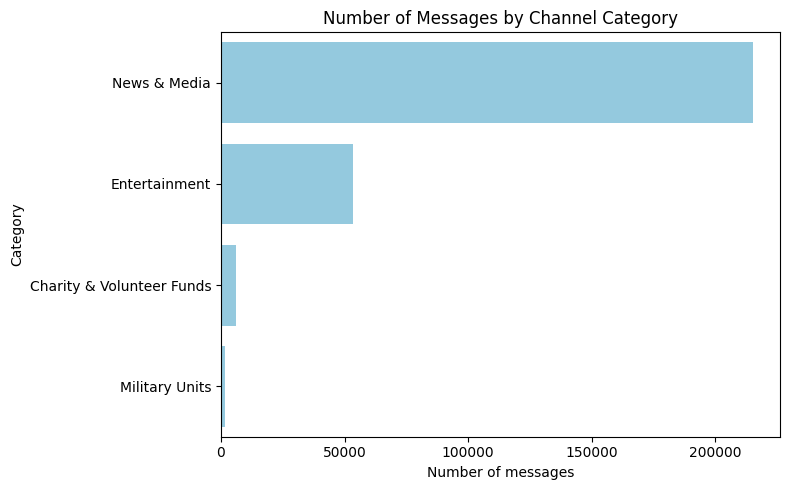

In [ ]:
category_counts = full_df['category'].value_counts()

plt.figure(figsize=(8, 5))
sns.barplot(x=category_counts.values, y=category_counts.index, color='skyblue')
plt.title('Number of Messages by Channel Category')
plt.xlabel('Number of messages')
plt.ylabel('Category')
plt.tight_layout()
plt.show()

**Interpretation:** grouping channels into categories rebalances the unit of comparison from 10 uneven individual channels to 5 thematic groups. The category-level distribution still reflects the underlying channel-size imbalance (e.g. News remains large because it contains the highest-volume channels), so category-level comparisons of *rates* (reactions per message, posts per day) rather than raw totals will be more informative for any follow-up analysis.

#### 1.7 Final overview

In [ ]:
import io

num_rows, num_cols = full_df.shape

buffer = io.BytesIO()
full_df.to_csv(buffer, index=False, encoding='utf-8')
csv_size_mb = buffer.tell() / (1024 ** 2)

overview_data = [
    {"Metric": "Dataset Shape", "Value": f"{num_rows:,} rows × {num_cols} columns"},
    {"Metric": "Total Records (Rows)", "Value": f"{num_rows:,}"},
    {"Metric": "Total Features (Columns)", "Value": f"{num_cols:,}"},
    {"Metric": "CSV Export File Size", "Value": f"{csv_size_mb:.2f} MB"}
]

dim_overview_df = pd.DataFrame(overview_data)

display(dim_overview_df.style.hide(axis='index').set_properties(**{'text-align': 'left'}))

Metric,Value
Dataset Shape,"408,357 rows × 18 columns"
Total Records (Rows),"408,357"
Total Features (Columns),18
CSV Export File Size,866.83 MB


#### 1.8 CSV export

In [ ]:
import os

csv_output_path = '/content/drive/MyDrive/H2_CSS/telegram_cleaned.csv'

print("Exporting dataset to CSV...")
full_df.to_csv(csv_output_path, index=False, encoding='utf-8')
print("Dataset successfully exported!")

file_size_bytes = os.path.getsize(csv_output_path)
file_size_mb = file_size_bytes / (1024 ** 2)
file_size_gb = file_size_bytes / (1024 ** 3)

print(f"\nFile path: {csv_output_path}")
print(f"Disk size: {file_size_mb:.2f} MB ({file_size_gb:.2f} GB)")

Exporting dataset to CSV...
Dataset successfully exported!

File path: /content/drive/MyDrive/H2_CSS/telegram_cleaned.csv
Disk size: 866.83 MB (0.85 GB)
